# Feature-grounded variance decomposition: a tutorial

This notebook shows how to apply the method to **your own** latent space in a few lines using the
`FeatureGroundedDecomposition` class. The idea: given low-dimensional latent codes from any encoder
(VAE, autoencoder, PCA, ...) and a bank of interpretable features (radiomics, hand-crafted descriptors,
metadata), ask for each latent direction *what fraction of its variance the features explain, and how
that explained variance splits across feature groups and individual features.* The unexplained
remainder is the irreducible (noise) part of the direction.

## Inputs

| input | shape | meaning |
|---|---|---|
| `df_latent` | `n x d` | latent codes, one column per latent dimension |
| `df_feat`   | `n x q` | interpretable features, one column per feature |
| `feat_to_group` | `q -> g` | dict mapping each feature name to its group name |

## Outputs

- **`scree()`** &mdash; figure: a `d`-dimensional vector of variance carried by each latent direction.
- **`shap()`** &mdash; group-level Shapley budget: a `(d+1) x (g+1)` table, the scalar `rho`, and a figure.
- **`johnson()`** &mdash; per-feature Johnson relative-weight budget: a `(d+1) x (q+1)` table, `rho`, and a figure.

In both tables every row is a latent direction (plus a final eigenvalue-weighted-sum row). The columns
are the attribution shares plus a final `noise` column: the group Shapley shares (or per-feature relative
weights) and the noise remainder **partition each direction's variance, so every row sums to 1**.

Two quantities are deliberately kept *out* of the budget tables and exposed as object-level vectors,
because they are on the variance scale rather than the share scale and are shared by both views:
`decomp.variance_fraction` (the eigenvalue weight of each direction) and `decomp.r2` (the total explained
fraction `R^2 = 1 - noise` of each direction).

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fgvb

rng = np.random.default_rng(0)

## 2. Build an example dataset

So the notebook runs standalone, we synthesize a small dataset with known structure. Replace this cell
with your own `df_latent`, `df_feat`, and `feat_to_group` (see the template in section 6).

We create three feature groups &mdash; `shape`, `texture`, `intensity` &mdash; and build a latent space
whose directions are driven by these features to varying degrees, plus additive noise. Because the latent
is a linear function of the features plus noise, the method should recover a high `rho` and attribute the
variance to the groups that actually drive each direction.

In [6]:
n = 500

# Three groups of interpretable features.
shape_f     = rng.normal(size=(n, 3))
texture_f   = rng.normal(size=(n, 3))
intensity_f = rng.normal(size=(n, 2))
F = np.hstack([shape_f, texture_f, intensity_f])

feature_names = (
    [f"shape_{i}" for i in range(3)]
    + [f"texture_{i}" for i in range(3)]
    + [f"intensity_{i}" for i in range(2)]
)
df_feat = pd.DataFrame(F, columns=feature_names)

# feature name -> group name
feat_to_group = {name: name.split("_")[0] for name in feature_names}

# A d=6 latent space; each latent column is a random mixture of the features + noise.
d = 6
mixing = rng.normal(size=(F.shape[1], d))
noise = 0.6 * rng.normal(size=(n, d))
Z = F @ mixing + noise
df_latent = pd.DataFrame(Z, columns=[f"z{i}" for i in range(d)])

print(f"Latent space ({df_latent.shape}):")
display(df_latent.head())
print(f"Feature space ({df_feat.shape}):")
display(df_feat.head())
print("Feature to group mapping:", feat_to_group)

Latent space ((500, 6)):


,z0,z1,z2,z3,z4,z5
0,-4.261775,4.390647,-0.748269,-0.804359,-3.832976,-0.438682
1,3.101773,8.374054,0.755364,-2.195592,2.215366,2.710561
2,-1.894458,-0.998979,-0.341816,-0.252763,-1.831943,-0.770483
3,1.785498,1.654562,-5.108882,2.801103,-1.096044,-2.104655
4,-1.045014,-5.670122,1.606248,-2.248487,-0.072962,0.468093


Feature space ((500, 8)):


,shape_0,shape_1,shape_2,texture_0,texture_1,texture_2,intensity_0,intensity_1
0,0.979644,-0.030037,1.781625,1.092239,-1.269850,0.122429,-1.243784,-0.706612
1,1.074981,0.621773,1.679868,2.447515,0.104674,-0.342842,-0.509231,0.982977
2,-0.725212,-0.462717,0.451710,0.312181,0.179057,-0.541809,0.465779,-0.763245
3,-0.617965,0.760681,1.380489,-0.563325,0.217925,1.228779,-2.097823,0.606739
4,-1.730401,-0.446051,-0.872810,-1.219422,-0.043962,-1.808934,0.892698,0.239385


Feature to group mapping: {'shape_0': 'shape', 'shape_1': 'shape', 'shape_2': 'shape', 'texture_0': 'texture', 'texture_1': 'texture', 'texture_2': 'texture', 'intensity_0': 'intensity', 'intensity_1': 'intensity'}


## 3. Fit the decomposition

Construct the class with the three inputs. By default the latent **directions** are the principal
directions of the latent covariance (`mode="eigen"`); pass `mode="axes"` to analyze the raw latent
columns instead. The fit is computed lazily and cached on first use.

In [3]:
decomp = fgvb.FeatureGroundedDecomposition(
    df_latent,
    df_feat,
    feat_to_group,
    mode="eigen",       # "eigen" (principal directions) or "axes" (raw latent columns)
    n_directions=None,  # analyze all d directions; set an int to keep only the top-k
    cv_folds=5,
    seed=0,
)
decomp

FeatureGroundedDecomposition(n=500, d=6, q=8, groups=3, mode='eigen', fitted=False)

In [4]:
import inspect

_init_params = set(inspect.signature(decomp.__init__).parameters)
members = [(name, val) for name, val in inspect.getmembers(decomp)
           if not name.startswith('_') and name not in _init_params]

print("=== Methods ===")
for name, val in members:
    if callable(val):
        print(f"{name}")

print("\n=== Attributes ===")
for name, val in members:
    if not callable(val):
        print(f"{name}: {type(val).__name__}")

=== Methods ===
global_budget
johnson
scree
shap

=== Attributes ===
directions: list
eigvals: ndarray
eigvecs: ndarray
feature_names: list
global_group_shares: dict
global_noise: float
group_names: list
groups: dict
r2: Series
rho: float
rho_cv: float
variance_fraction: Series


In [5]:
# Headline scalar: fraction of the WHOLE latent space's variance the features explain.
print(f"rho = {decomp.rho:.3f}  (features explain {decomp.rho*100:.1f}% of latent variance)")
# The cross-validated, out-of-sample version:
print(f"rho (cross-validated) = {decomp.rho_cv:.3f}")

rho = 0.964  (features explain 96.4% of latent variance)
rho (cross-validated) = 0.962


## 4. Scree: how much variance each direction carries

The scree plot shows the fraction of total latent variance carried by each direction (ordered by
variance). Directions on the left dominate the eigenvalue-weighted summaries below. The same numbers
are available as a vector via `decomp.variance_fraction`.

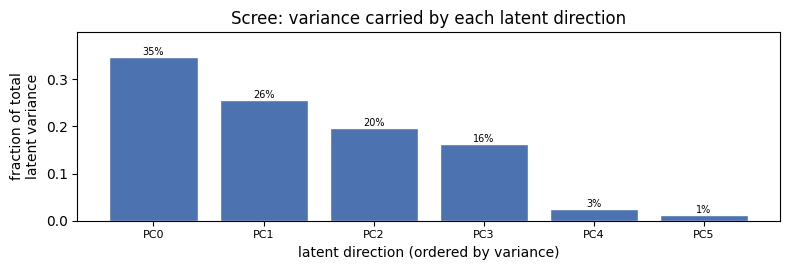

PC0             0.348
PC1             0.255
PC2             0.197
PC3             0.162
PC4             0.025
PC5             0.012
weighted_sum    1.000
Name: variance_fraction, dtype: float64

In [6]:
# fig_out=None (default) just returns the figure; pass a path to also save it,
# or fig_out=True to save to the default location figures/scree.png.
fig = decomp.scree(fig_out="figures/scree.png")
plt.show()

decomp.variance_fraction.round(3)

## 5a. SHAP: group-level variance budget

`shap()` returns three things: the `(d+1) x (g+1)` **table**, the scalar **`rho`**, and a **figure**.
Each row is a latent direction; the final `weighted_sum` row is the eigenvalue-weighted aggregate (the
global budget). The group columns are the Shapley shares of `R^2` (non-negative, collinearity-aware);
the final `noise` column is `1 - R^2`. Group shares plus noise partition each direction's variance, so
**every row sums to 1**.

The figure defaults to `figure_type="bar"` (one stacked bar per direction); pass `figure_type="heatmap"`
for a direction-by-group grid. Pass `feat_to_group=...` to regroup the features for this call only,
recomputing the Shapley attribution without re-fitting the decomposition. Because the exact Shapley game
is exponential in the number of groups, `shap()` warns when there are too many groups and suggests
pooling features.</cell id="54a475f6">

rho = 0.964


,shape,texture,intensity,noise
direction,,,,
PC0,0.347,0.568,0.067,0.018
PC1,0.047,0.840,0.090,0.023
PC2,0.232,0.338,0.401,0.029
PC3,0.112,0.428,0.420,0.040
PC4,0.530,0.127,0.129,0.213
PC5,0.329,0.088,0.075,0.507
weighted_sum,0.214,0.552,0.198,0.036


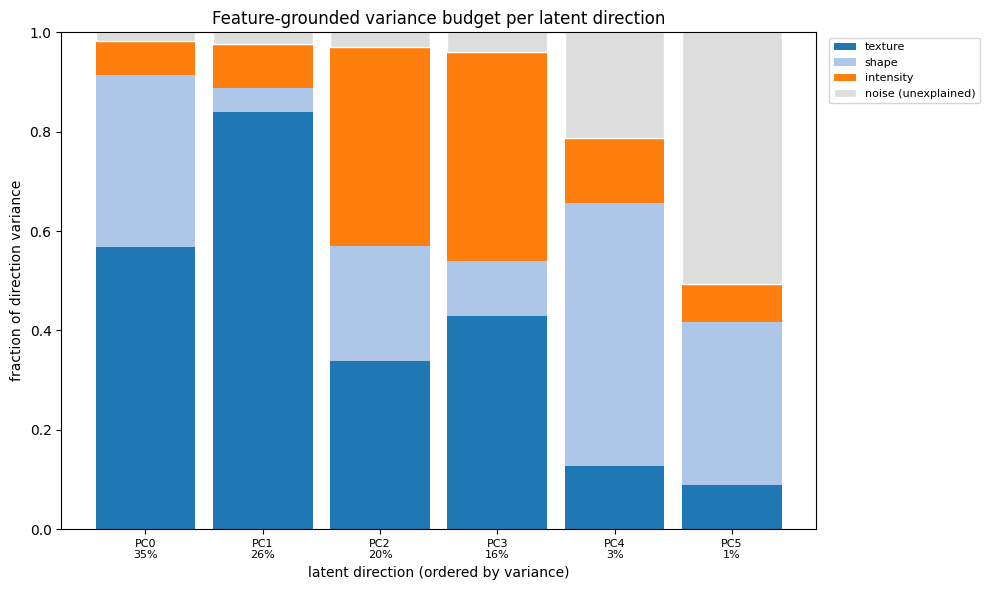

In [7]:
# fig_out saves the per-direction SHAP budget (one stacked bar per direction).
shap_table, rho, shap_fig = decomp.shap(fig_out="figures/shap_budget.png")
print(f"rho = {rho:.3f}")
shap_table.round(3)

In [8]:
# Each bar is one direction; segments are the group Shapley shares plus the noise remainder (bars sum to 1).
plt.show()

## 5b. Johnson: per-feature variance budget

`johnson()` refines the attribution from groups to individual features. It returns the
`(d+1) x (q+1)` table, the scalar `rho`, and a figure. The per-feature relative weights plus noise
again sum to 1 in every row, so the Johnson and SHAP tables are consistent refinements of the same
explained variance.

The figure defaults to `figure_type="heatmap"` (a direction-by-feature grid showing the top `top_n`
features by their global relative weight); pass `figure_type="bar"` for a per-direction stacked bar
that lumps all but the top `top_n` features into an `other` segment. The table always carries all `q`
features regardless of `top_n`.</cell id="6eb05591">

rho = 0.964


,shape_0,shape_1,shape_2,texture_0,texture_1,texture_2,intensity_0,intensity_1,noise
direction,,,,,,,,,
PC0,0.029,0.278,0.040,0.111,0.042,0.415,0.067,0.001,0.018
PC1,0.004,0.011,0.033,0.046,0.788,0.005,0.081,0.010,0.023
PC2,0.149,0.004,0.079,0.054,0.038,0.245,0.182,0.219,0.029
PC3,0.097,0.014,0.001,0.334,0.002,0.093,0.201,0.218,0.040
PC4,0.283,0.126,0.122,0.002,0.004,0.120,0.050,0.079,0.213
PC5,0.024,0.001,0.304,0.081,0.001,0.006,0.075,0.001,0.507
weighted_sum,0.064,0.106,0.045,0.116,0.224,0.212,0.115,0.083,0.036


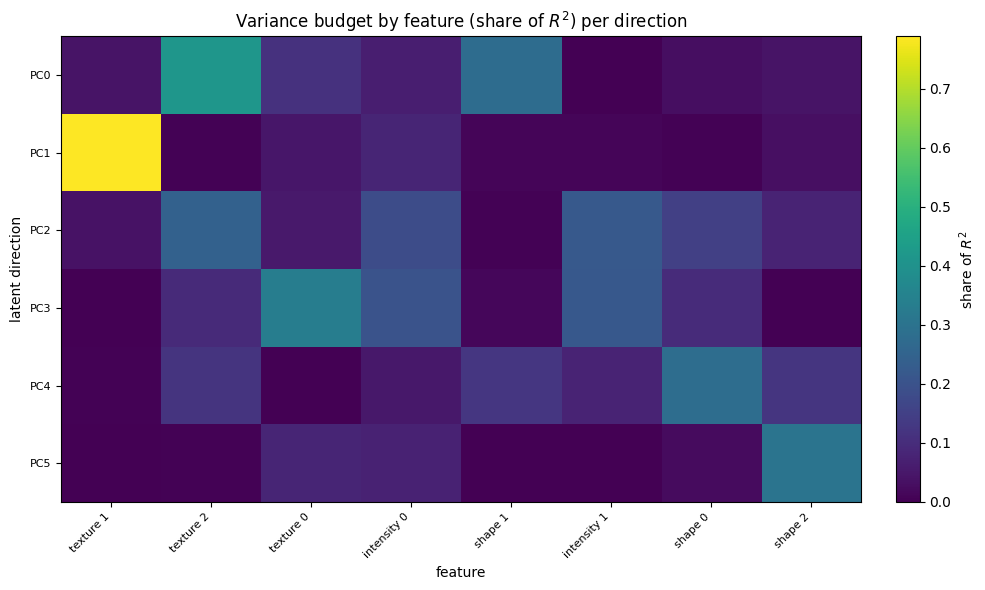

In [9]:
johnson_table, rho, johnson_fig = decomp.johnson(top_n=20, fig_out="figures/johnson_budget.png")
print(f"rho = {rho:.3f}")
johnson_table.round(3)

In [10]:
plt.show()

## 5d. Global budget: the whole latent space in one bar

`global_budget()` collapses the per-direction budget into a single stacked bar &mdash; the
eigenvalue-weighted `weighted_sum` row of the tables above. Use `by="group"` for the Shapley group
budget or `by="feature"` for the Johnson per-feature budget (which keeps the `top_n` largest features
and lumps the rest into an `other` segment). Each bar sums to 1.

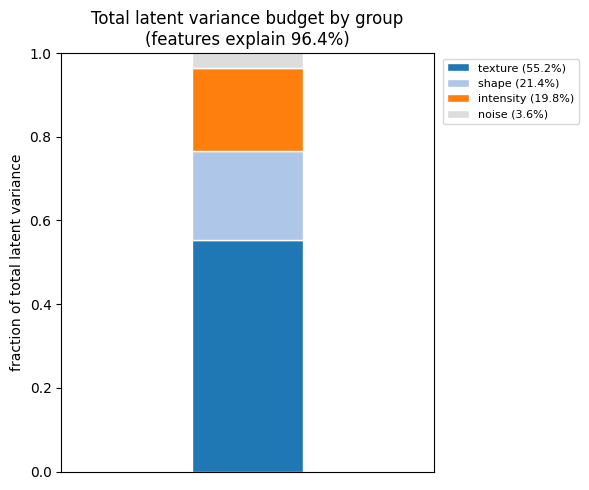

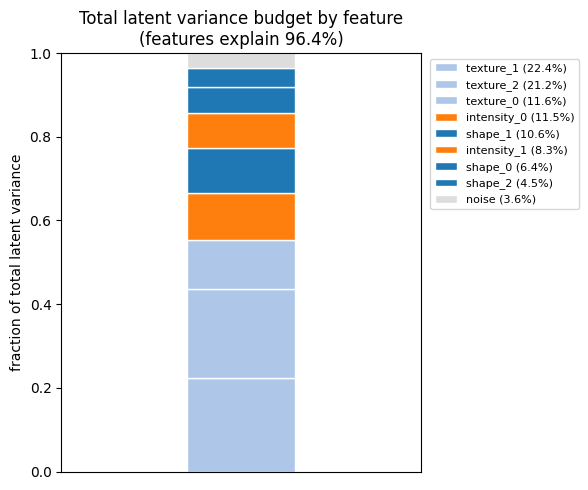

In [11]:
# global_budget also takes fig_out (None=return only, a path=save there,
# True=save to figures/global_budget_<by>.png).
fig_group = decomp.global_budget(by="group", fig_out="figures/global_budget.png")
fig_feat = decomp.global_budget(by="feature", top_n=8)
plt.show()

## 5c. The two vectors kept out of the tables

The eigenvalue weight and the total explained fraction `R^2` of each direction are shared by both the
SHAP and Johnson views, so they live on the object instead of being duplicated as table columns.

In [12]:
summary = pd.concat([decomp.variance_fraction, decomp.r2], axis=1)
summary.round(3)

,variance_fraction,r2
PC0,0.348,0.982
PC1,0.255,0.977
PC2,0.197,0.971
PC3,0.162,0.960
PC4,0.025,0.787
PC5,0.012,0.493
weighted_sum,1.000,0.964


### Sanity checks on the additive budget

The decompositions are exact, so these identities hold to numerical precision.

In [13]:
assert np.allclose(shap_table.sum(axis=1), 1.0), "each SHAP row should sum to 1"
assert np.allclose(johnson_table.sum(axis=1), 1.0), "each Johnson row should sum to 1"
# R^2 = 1 - noise, and it equals the row sum of the attribution columns.
assert np.allclose(decomp.r2.values, 1.0 - shap_table["noise"].values)
assert np.allclose(decomp.r2.values, 1.0 - johnson_table["noise"].values)
# The weighted-sum row matches the global summaries.
assert np.isclose(decomp.r2["weighted_sum"], decomp.rho)
print("All additive-budget identities hold.")

All additive-budget identities hold.
